In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Data Ingestion

Read in [this dataset](https://github.com/fedhere/FDSFE_FBianco/blob/main/data/titanic_train.csv). Be sure to use the raw file when reading with Pandas.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/fedhere/FDSFE_FBianco/refs/heads/main/data/titanic_train.csv")

# Data exploration

1. Check the shape of the dataset.
2. Check the first few rows of the dataset.
3. Check the last few rows of the dataset.
4. Check `df.info()` to see the data types in the dataset and check for missing entries.
5. Check `df.describe()` to get a feel for the spread of the data and check for missing entries.

In [ ]:
df.shape

(891, 12)

In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data preparation: Restricting the dataset

We are only going to use the following columns from this dataset:
* `Survived`: Whether or not the passenger survived the titanic disaster. This is what our model will predict, it is our "target class". What kind of data is this?
* `Pclass`: The class of ticket the passenger had. Can be 1st class, 2nd class or 3rd class.
* `Sex`: Gender of the passenger encoded as "male" or "female".
* `Age`: Age of the passenger.

We will be using the data in `Pclass`, `Sex` and `Age` to predict whether or not the passenger survived.

**We are answering the question:** how did ticket class, gender and age affect one's chances of surviving the titanic disaster?

## Step 1: Turn the `Sex` column from strings into numbers.

Create a new column called `gender` which encodes "male" as 0 and "female" as 1.

In [ ]:
male_female_to_0_1 = {
    "male": 0,
    "female": 1,
}

In [ ]:
df["Sex"].unique()

array(['male', 'female'], dtype=object)

In [ ]:
df["gender"] = df["Sex"].map(male_female_to_0_1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,gender
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0


## Step 2: One-hot encode the `Pclass` column.

`Pclass` is the ticket class of the passenger and can be either 1, 2 or 3.

In [ ]:
import numpy as np

In [ ]:
np.unique(df["Pclass"], return_counts=True)

(array([1, 2, 3]), array([216, 184, 491]))

In [ ]:
df = pd.get_dummies(df, columns=["Pclass"], dtype=int, prefix="TicketClass")
df

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,gender,TicketClass_1,TicketClass_2,TicketClass_3
0,1,0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,0,0,1
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,1,0,0
2,3,1,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0,0,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,1,0,0
4,5,0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,0,0,1,0
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1,1,0,0
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1,0,0,1
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,1,0,0


## Step 3: The `Age` column is fine. Now make a new dataframe that has only the columns we care about.

In [ ]:
from matplotlib import pyplot as plt

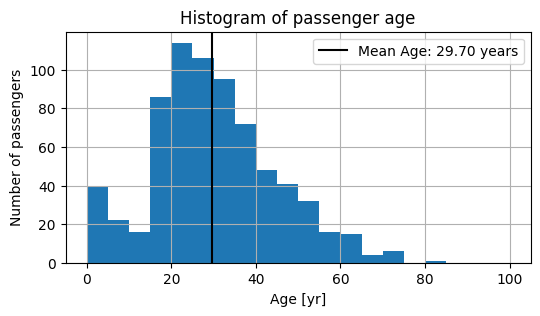

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title("Histogram of passenger age")
df["Age"].hist(ax=ax, range=(0, 100), bins=20)

mean_age = df["Age"].mean()
ax.axvline(x=mean_age, c="k", label=f"Mean Age: {mean_age:.2f} years")

ax.set_xlabel("Age [yr]")
ax.set_ylabel("Number of passengers")

ax.legend(loc="upper right")
fig.show()

This is a histogram of the ages of the passengers on the Titanic. The size of the histogram bins is 5 years. The average age of the passengers is 29.70 years. This figure illustrates how most passengers are young. Note that there is a secondary peak in the histogram for passengers aged five and below.

In [ ]:
columns_we_dont_want = [
    "PassengerId",
    "Name",
    "Sex",
    "SibSp",
    "Parch",
    "Ticket",
    "Fare",
    "Cabin",
    "Embarked"
]

df_new = df.drop(columns=columns_we_dont_want)
df_new

,Survived,Age,gender,TicketClass_1,TicketClass_2,TicketClass_3
0,0,22.0,0,0,0,1
1,1,38.0,1,1,0,0
2,1,26.0,1,0,0,1
3,1,35.0,1,1,0,0
4,0,35.0,0,0,0,1
...,...,...,...,...,...,...
886,0,27.0,0,0,1,0
887,1,19.0,1,1,0,0
888,0,NaN,1,0,0,1
889,1,26.0,0,1,0,0


In [ ]:
df_new.dropna(inplace=True)
df_new

,Survived,Age,gender,TicketClass_1,TicketClass_2,TicketClass_3
0,0,22.0,0,0,0,1
1,1,38.0,1,1,0,0
2,1,26.0,1,0,0,1
3,1,35.0,1,1,0,0
4,0,35.0,0,0,0,1
...,...,...,...,...,...,...
885,0,39.0,1,0,0,1
886,0,27.0,0,0,1,0
887,1,19.0,1,1,0,0
889,1,26.0,0,1,0,0


In [ ]:
rows_lost = df.shape[0] - df_new.shape[0]
print(f"We lost {rows_lost} rows when removing NaNs.")

We lost 177 rows when removing NaNs.


In [ ]:
(df_new.shape[0] - df.shape[0]) / df.shape[0]

-0.19865319865319866

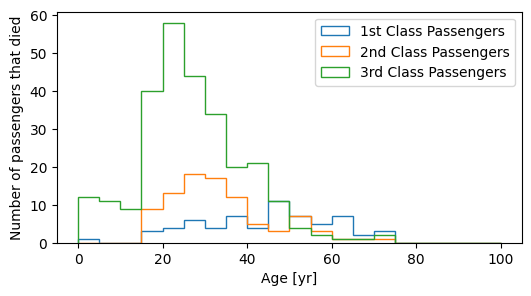

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.hist(df_new["Age"][(df_new["TicketClass_1"] == 1) & (df_new["Survived"] == 0)], range=(0, 100), bins=20, histtype="step", label="1st Class Passengers")
ax.hist(df_new["Age"][(df_new["TicketClass_2"] == 1) & (df_new["Survived"] == 0)], range=(0, 100), bins=20, histtype="step", label="2nd Class Passengers")
ax.hist(df_new["Age"][(df_new["TicketClass_3"] == 1) & (df_new["Survived"] == 0)], range=(0, 100), bins=20, histtype="step", label="3rd Class Passengers")

ax.set_xlabel("Age [yr]")
ax.set_ylabel("Number of passengers that died")
ax.legend(loc="upper right")

fig.show()

## Step 4: Remove any rows that have missing values.

How many rows did we lose?

## Step 5: Train-test split

First we must declare our features (`x`) and our target (`y`) arrays.

In [ ]:
X = df_new[["Age", "gender", "TicketClass_1", "TicketClass_2", "TicketClass_3"]].values
X

array([[22.,  0.,  0.,  0.,  1.],
       [38.,  1.,  1.,  0.,  0.],
       [26.,  1.,  0.,  0.,  1.],
       ...,
       [19.,  1.,  1.,  0.,  0.],
       [26.,  0.,  1.,  0.,  0.],
       [32.,  0.,  0.,  0.,  1.]])

In [ ]:
Y = df_new["Survived"].values
Y

array([0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,

In [ ]:
np.unique(Y, return_counts=True)

(array([0, 1]), array([424, 290]))

In [ ]:
Xtrn, Xtst, Ytrn, Ytst = train_test_split(X, Y, random_state=1415, train_size=0.7, stratify=Y)
Xtrn.shape, Xtst.shape, Ytrn.shape, Ytst.shape

((499, 5), (215, 5), (499,), (215,))

## Step 6: Train a Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(max_depth=2, random_state=1415)
dtc.fit(Xtrn, Ytrn)

DecisionTreeClassifier(max_depth=2, random_state=1415)

In [ ]:
dtc.score(Xtrn, Ytrn)

0.8076152304609219

In [ ]:
dtc.score(Xtst, Ytst)

0.7813953488372093

In [ ]:
dtc.feature_importances_

array([0.06079814, 0.76219613, 0.        , 0.        , 0.17700573])

In [ ]:
df_new.columns

Index(['Survived', 'Age', 'gender', 'TicketClass_1', 'TicketClass_2',
       'TicketClass_3'],
      dtype='object')

## Step 7: Ensemble Methods and their Hyperparameters

In [ ]:
from sklearn import ensemble
rfc = ensemble.RandomForestClassifier(n_estimators=100, max_depth=3, random_state=1415)
rfc.fit(Xtrn, Ytrn)

RandomForestClassifier(max_depth=3, random_state=1415)

In [ ]:
rfc.score(Xtrn, Ytrn)

0.8236472945891784

In [ ]:
rfc.score(Xtst, Ytst)

0.7813953488372093

In [ ]:
gbc = ensemble.GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=1415)
gbc.fit(Xtrn, Ytrn)

GradientBoostingClassifier(max_depth=5, random_state=1415)

In [ ]:
gbc.score(Xtrn, Ytrn)

0.8957915831663327

In [ ]:
gbc.score(Xtst, Ytst)

0.8093023255813954